In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import gymnasium as gym
import yaml
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../envs"))
sys.path.append(os.path.abspath("../models"))
sys.path.append(os.path.abspath("../src"))

from utils_q_learning import *

In [3]:
with open("../config/q_learning_config.yaml", "r") as f:
    config = yaml.safe_load(f)

### 1)

In [4]:
experiment_folder = "parte1_1"

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)

episodes = config[experiment_folder]["episodes"]
alpha = config[experiment_folder]["alpha"]
gamma = config[experiment_folder]["gamma"]
epsilon = config[experiment_folder]["epsilon"]
seed = config["xtra"]["seed"]

model_1_path, _ = train_q_learning(experiment_folder, env, episodes, alpha, gamma, epsilon, seed=seed)

In [5]:
experiment_folder = "parte1_1"

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)
seed = config["xtra"]["seed"]

success_rate = evaluate_Q(model_1_path, env, episodes=100, epsilon=0.0, seed=seed)
print(f"Success rate: {success_rate:.2f}")

Success rate: 0.06


### 2)

In [6]:
experiment_folder = "parte1_2"

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)

episodes = config[experiment_folder]["episodes"]
gamma = config[experiment_folder]["gamma"]
seed = config["xtra"]["seed"]
alphas = [0.5, 0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001]
epsilons = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
best_a_eps = search_hyperparameters(experiment_folder, env, episodes, gamma, alphas, epsilons, seed=seed)

Searching hyper:   0%|          | 0/88 [00:00<?, ?it/s]

Best epsilon for alpha 0.5: 0.2 with success rate 0.65
Best epsilon for alpha 0.1: 0.4 with success rate 0.76
Best epsilon for alpha 0.05: 0.3 with success rate 0.76
Best epsilon for alpha 0.01: 0.9 with success rate 0.47
Best epsilon for alpha 0.005: 0.4 with success rate 0.37
Best epsilon for alpha 0.001: 0.4 with success rate 0.25
Best epsilon for alpha 0.0005: 0.4 with success rate 0.25


In [7]:
experiment_folder = "parte1_2"

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)

episodes = config[experiment_folder]["episodes"]
gamma = config[experiment_folder]["gamma"]
seed = config["xtra"]["seed"]
alphas = best_a_eps.keys()
epsilons = best_a_eps.values()
results = []
for alpha, eps in zip(alphas, epsilons):  # to save the Q
    path, _ = train_q_learning(experiment_folder, env, episodes, alpha, gamma, eps, seed=seed)
    success_rate = evaluate_Q(path, env, episodes=100, epsilon=0.0, seed=seed)
    results.append((success_rate, alpha, eps))
    print(f"Alpha: {alpha}, Epsilon: {eps}, Success Rate: {success_rate:.2f}")

Alpha: 0.5, Epsilon: 0.2, Success Rate: 0.65
Alpha: 0.1, Epsilon: 0.4, Success Rate: 0.76
Alpha: 0.05, Epsilon: 0.3, Success Rate: 0.76
Alpha: 0.01, Epsilon: 0.9, Success Rate: 0.47
Alpha: 0.005, Epsilon: 0.4, Success Rate: 0.37
Alpha: 0.001, Epsilon: 0.4, Success Rate: 0.25
Alpha: 0.0005, Epsilon: 0.4, Success Rate: 0.25
Alpha: 0.0001, Epsilon: 0.4, Success Rate: 0.25


In [8]:
experiment_folder = "parte1_2"

# results should be a list of (success_rate, alpha, eps) from the previous cell
results_sorted = sorted(results, key=lambda x: x[0])
best_success_rate, best_alpha, best_epsilon = results_sorted[-1]
print(f"Best alpha: {best_alpha}, Best epsilon: {best_epsilon}")
config[experiment_folder]["best_alpha"] = best_alpha
config[experiment_folder]["best_epsilon"] = best_epsilon
with open("../config/q_learning_config.yaml", "w") as f:
    yaml.safe_dump(config, f, sort_keys=False)

Best alpha: 0.05, Best epsilon: 0.3


### 3)

In [9]:
experiment_folder = "parte1_2"

episodes = config[experiment_folder]["episodes"]
alpha = config[experiment_folder]["best_alpha"]
gamma = config[experiment_folder]["gamma"]
epsilon = config[experiment_folder]["best_epsilon"]

seed = config["xtra"]["seed"]
env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)
model3_path, _ = train_q_learning(experiment_folder, env, episodes, alpha, gamma, epsilon, seed=seed)

Experiment ../runs/q_learning/parte1_2/epi_5000_a_0.05_g_0.99_eps_0.3 already exists.


In [10]:
env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)
seed = config["xtra"]["seed"]
epsilons = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
succ_rates = []
for epsilon in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    success_rate = evaluate_Q(model3_path, env, episodes=100, epsilon=epsilon, seed=seed)
    succ_rates.append(success_rate)
    print(f"Success rate for epsilon {epsilon}: {success_rate:.2f}")


Success rate for epsilon 0.0: 0.76
Success rate for epsilon 0.1: 0.42
Success rate for epsilon 0.2: 0.27
Success rate for epsilon 0.3: 0.16
Success rate for epsilon 0.4: 0.17
Success rate for epsilon 0.5: 0.07
Success rate for epsilon 0.6: 0.06
Success rate for epsilon 0.7: 0.02
Success rate for epsilon 0.8: 0.04
Success rate for epsilon 0.9: 0.02
Success rate for epsilon 1.0: 0.01


In [11]:
experiment_2 = "parte1_2"
experiment_folder = "parte1_4"
config[experiment_folder]["gamma"] = config[experiment_2]["gamma"]
config[experiment_folder]["alpha"] = config[experiment_2]["best_alpha"]
with open("../config/q_learning_config.yaml", "w") as f:
    yaml.safe_dump(config, f, sort_keys=False)

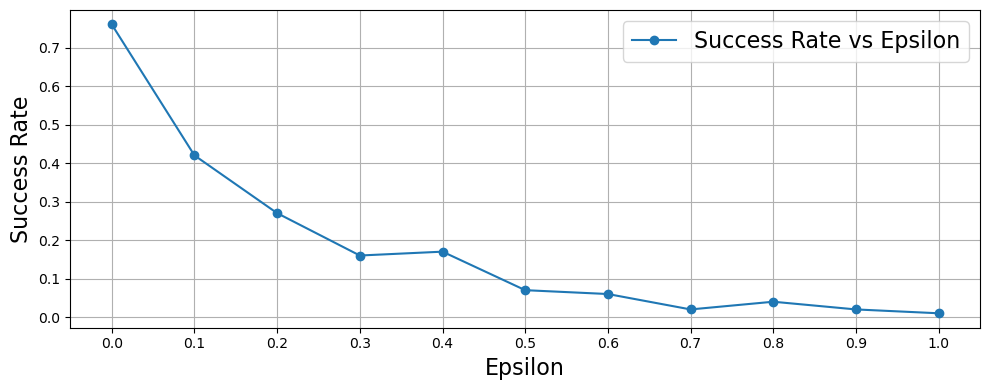

In [12]:
fig = plt.figure(figsize=(10, 4))
plt.plot(epsilons, succ_rates, marker='o', label="Success Rate vs Epsilon")
plt.xlabel("Epsilon", fontsize=16)
plt.ylabel("Success Rate", fontsize=16)
plt.xticks(epsilons)
plt.grid()
plt.tight_layout()
plt.legend(fontsize = 16)
path = Path("../images/succes_rate_vs_epsilon.png")
if not os.path.exists(path.parent):
    os.makedirs(path.parent)
plt.savefig(path, dpi=300)
plt.show()

### 4)

In [ ]:
experiment_folder = "parte1_4"

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)

episodes = config[experiment_folder]["episodes"]
gamma = config[experiment_folder]["gamma"]
alpha = config[experiment_folder]["alpha"]
seed = config["xtra"]["seed"]
min_epsilons = [0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 0.9]
max_epsilons = [0.1, 0.2, 0.4, 0.6, 0.8, 0.9, 1.0]
decays_rate = [0.01, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 0.9, 1.0]
# min_epsilons = [0.1, 0.2]
# max_epsilons = [0.2, 0.4]
# decays_rate = [0.01, 0.05]
best_max_decay, global_best = search_eps_decay(experiment_folder, env, episodes, gamma, alpha, min_epsilons, max_epsilons, decays_rate, seed)

Total hyperparameter combinations to evaluate: 252


Searching hyper:   0%|          | 0/252 [00:00<?, ?it/s]

In [14]:
print(global_best)

{'min_epsilon': 0.1, 'max_epsilon': 0.2, 'decay_rate': 0.1, 'success_rate': 0.76}


In [15]:
experiment_4 = "parte1_4"
experiment_folder = "parte1_5"
config[experiment_folder]["gamma"] = config[experiment_4]["gamma"]
config[experiment_folder]["alpha"] = config[experiment_4]["alpha"]
config[experiment_folder]["min_epsilon"] = global_best["min_epsilon"]
config[experiment_folder]["max_epsilon"] = global_best["max_epsilon"]
config[experiment_folder]["decay_rate"] = global_best["decay_rate"]
with open("../config/q_learning_config.yaml", "w") as f:
    yaml.safe_dump(config, f, sort_keys=False)

### 5)

In [16]:
experiment_folder = "parte1_5"

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)

episodes = config[experiment_folder]["episodes"]
alpha = config[experiment_folder]["alpha"]
gamma = config[experiment_folder]["gamma"]
min_epsilon = config[experiment_folder]["min_epsilon"]
max_epsilon = config[experiment_folder]["max_epsilon"]
decay_rate = config[experiment_folder]["decay_rate"]
seed = config["xtra"]["seed"]

model_5_path, _ = train_q_learning(experiment_folder, env, episodes, alpha, gamma, min_epsilon, max_epsilon, decay_rate, seed=seed)

In [17]:
experiment_folder = "parte1_5"

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)
seed = config["xtra"]["seed"]

success_rate = evaluate_Q(model_5_path, env, episodes=100, epsilon=0.0, seed=seed)
print(f"Success rate: {success_rate:.2f}")

Success rate: 0.76


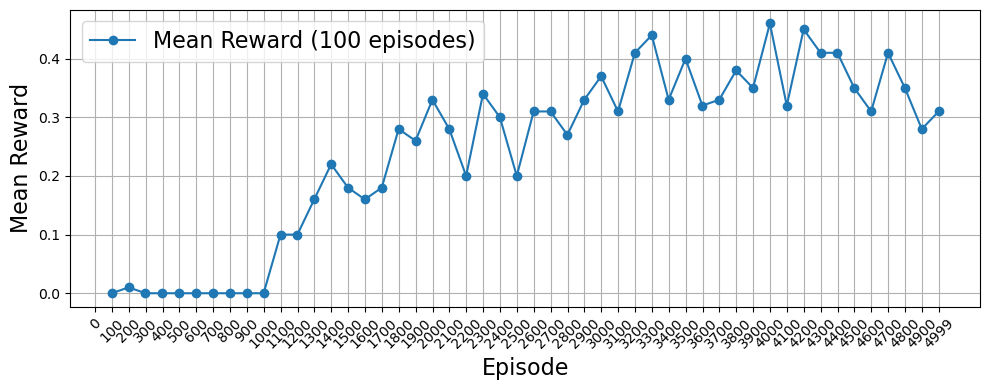

In [18]:
folder_name = "q_learning/parte1_5"
window = 100

plot_mean_rewards(folder_name, window)

### 6)

In [19]:
experiment_folder = "parte1_5"

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = None)

episodes = config[experiment_folder]["episodes"]
alpha = config[experiment_folder]["alpha"]
gamma = config[experiment_folder]["gamma"]
min_epsilon = config[experiment_folder]["min_epsilon"]
max_epsilon = config[experiment_folder]["max_epsilon"]
decay_rate = config[experiment_folder]["decay_rate"]
seed = config["xtra"]["seed"]

model_5_path, _ = train_q_learning(experiment_folder, env, episodes, alpha, gamma, min_epsilon, max_epsilon, decay_rate, seed=seed)

Experiment ../runs/q_learning/parte1_5/epi_5000_a_0.05_g_0.99_eps_0.1_max_eps_0.2_decay_0.1 already exists.


In [20]:
env = gym.make("FrozenLake-v1", is_slippery=True, render_mode = "rgb_array")
experiment_name = "Frozen_lake_video"
num_episodes = 1
epsilon = 0.0
seed = config["xtra"]["seed"]

record_experiment(model_5_path, experiment_name, env, num_episodes, epsilon, seed)

Episode 1 | Total reward: 1


/home/alumno1/miniconda3/envs/vision/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /home/alumno1/Documents/RL-TP2/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/home/alumno1/miniconda3/envs/vision/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
